# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [1]:
%pip install iso3166

Note: you may need to restart the kernel to use updated packages.


### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [2]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 2.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: plotly
    Found existing installation: plotly 5.23.0
    Uninstalling plotly-5.23.0:
      Successfully uninstalled plotly-5.23.0
Note: you may need to restart the kernel to use updated packages.


### Import Statements

In [3]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [4]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [5]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [8]:
print(df_data.shape)
print(df_data.columns)
df_data.head()

(4324, 9)
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')


,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [10]:
print(df_data.isna().sum())
print(df_data.duplicated().sum())

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64
0


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [19]:
df_clean = df_data[df_data['Price'].notna()]
print(df_clean.isna().sum())
df_clean = df_clean.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])
df_clean.head(2)

Unnamed: 0.1      0
Unnamed: 0        0
Organisation      0
Location          0
Date              0
Detail            0
Rocket_Status     0
Price             0
Mission_Status    0
dtype: int64


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success


## Descriptive Statistics

In [18]:
df_clean.describe()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,964,964,964,964,964,964,964
unique,25,56,963,962,2,56,4
top,CASC,"LC-39A, Kennedy Space Center, Florida, USA","Wed Nov 05, 2008 00:15 UTC",Long March 2D | Shiyan-3 & Chuangxin-1(02),StatusActive,450.0,Success
freq,158,120,2,2,586,136,910


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

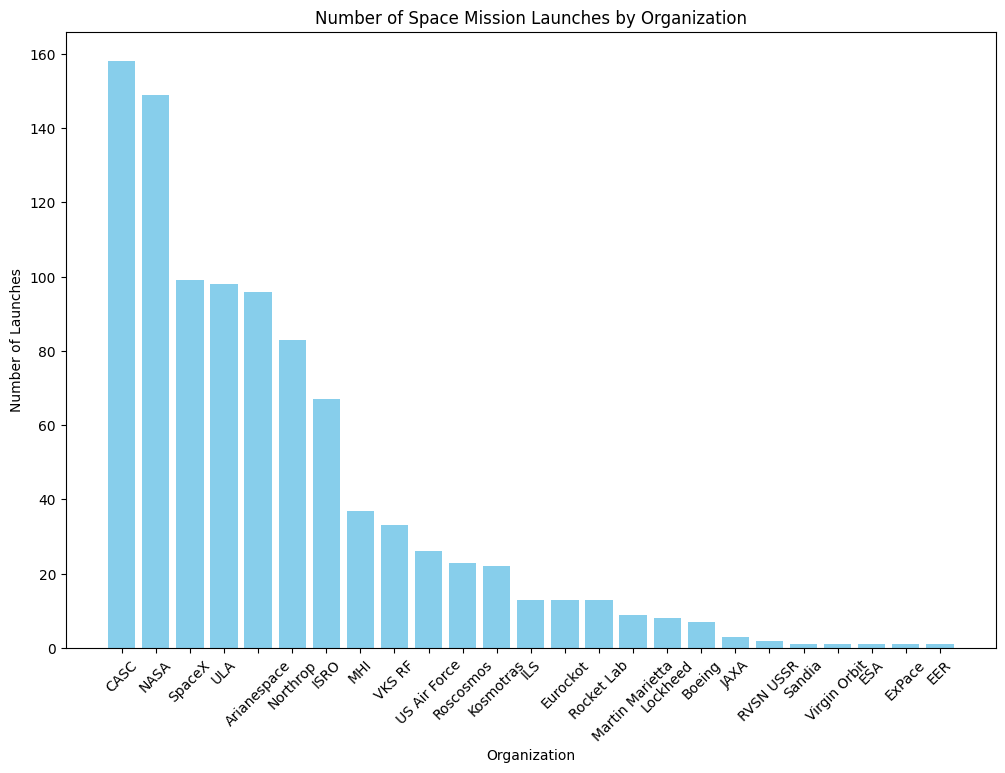

In [26]:
org_counts = df_clean.Organisation.value_counts()
org_counts

plt.figure(figsize=(12, 8))
plt.bar(org_counts.index, org_counts.values, color='skyblue')
plt.xlabel('Organization')
plt.ylabel('Number of Launches')
plt.title('Number of Space Mission Launches by Organization')
plt.xticks(rotation=45)
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [27]:
df_clean.Rocket_Status.value_counts()

Rocket_Status
StatusActive     586
StatusRetired    378
Name: count, dtype: int64

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [28]:
df_clean.Mission_Status.value_counts()

Mission_Status
Success              910
Failure               36
Partial Failure       17
Prelaunch Failure      1
Name: count, dtype: int64

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

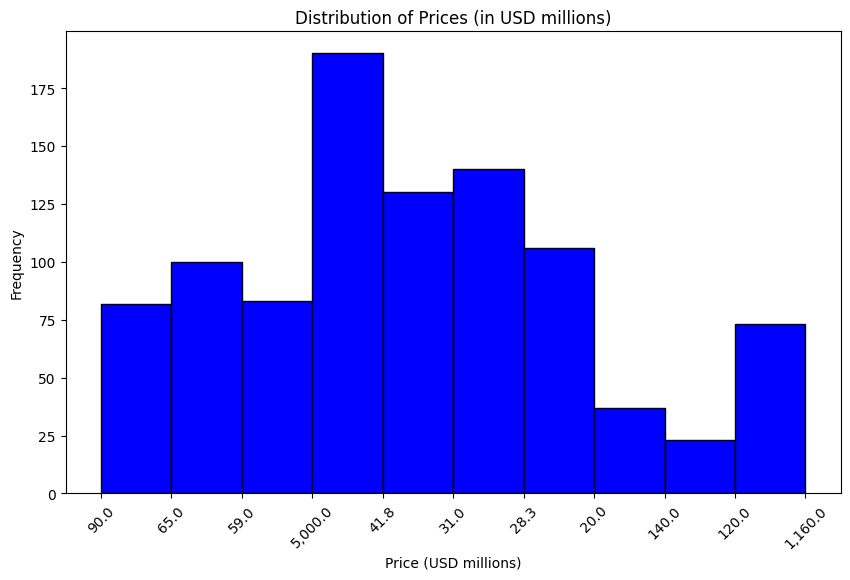

In [49]:
df_sorted = df_clean.sort_values("Price", ascending=False)
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(df_sorted.Price, bins=10, color='blue', edgecolor='black')
plt.xticks(bins, rotation=45)
plt.xlabel('Price (USD millions)')
plt.ylabel('Frequency')
plt.title('Distribution of Prices (in USD millions)')
plt.show()

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [54]:
df_clean['Country'] = df_clean['Location'].apply(lambda x: x.split(',')[-1].strip())
country_replacements = {
    "Russia": "Russian Federation",
    "New Mexico": "USA",
    "Yellow Sea": "China",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "USA",
    "Barents Sea": "Russian Federation",
    "Gran Canaria": "USA"
}

df_clean['Country'] = df_clean['Country'].replace(country_replacements)
df_clean.Country.value_counts()

Country
USA                   490
China                 159
France                 95
India                  67
Russian Federation     54
Kazakhstan             46
Japan                  40
New Zealand            13
Name: count, dtype: int64

In [59]:
def get_alpha3_code(country_name):
    try:
        return countries.get(country_name).alpha3
    except KeyError:
        return None

df_clean['Country_Code'] = df_clean['Country'].apply(get_alpha3_code)

df_clean['Country_Code'].value_counts()

Country_Code
USA    490
CHN    159
FRA     95
IND     67
RUS     54
KAZ     46
JPN     40
NZL     13
Name: count, dtype: int64

# Use a Choropleth Map to Show the Number of Failures by Country


In [73]:
df_failures = df_clean[df_clean['Mission_Status'] != 'Success']
df_failures_grouped = df_failures.groupby('Country_Code').size().reset_index(name='Failures')

fig = px.choropleth(
    df_failures_grouped,
    locations='Country_Code',
    color='Failures',
    hover_name='Country_Code',
    color_continuous_scale=px.colors.sequential.matter,
    title='Number of Launch Failures by Country'
)

# Update the layout for better visual appeal
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=False, projection_type='equirectangular'),
    coloraxis_colorbar=dict(title="Failures")
)

fig.show(renderer='browser')

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [75]:
df_sunburst = df_clean.groupby(['Country', 'Organisation', 'Mission_Status']).size().reset_index(name='Count')

# Create the Sunburst chart
fig = px.sunburst(
    df_sunburst,
    path=['Country', 'Organisation', 'Mission_Status'],
    values='Count',
    color='Count',
    color_continuous_scale=px.colors.sequential.matter,
    title='Sunburst Chart of Countries, Organisations, and Mission Status'
)

# Update the layout for better visual appeal
fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))

# Show the chart
fig.show(renderer='browser')

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [90]:
df_clean['Price'] = df_clean['Price'].str.replace(',', '', regex=True).astype(float)
df_clean.Price = pd.to_numeric(df_clean.Price)

total_spent_by_organisation = df_clean.groupby('Organisation')['Price'].sum().reset_index()
total_spent_by_organisation

AttributeError: Can only use .str accessor with string values!

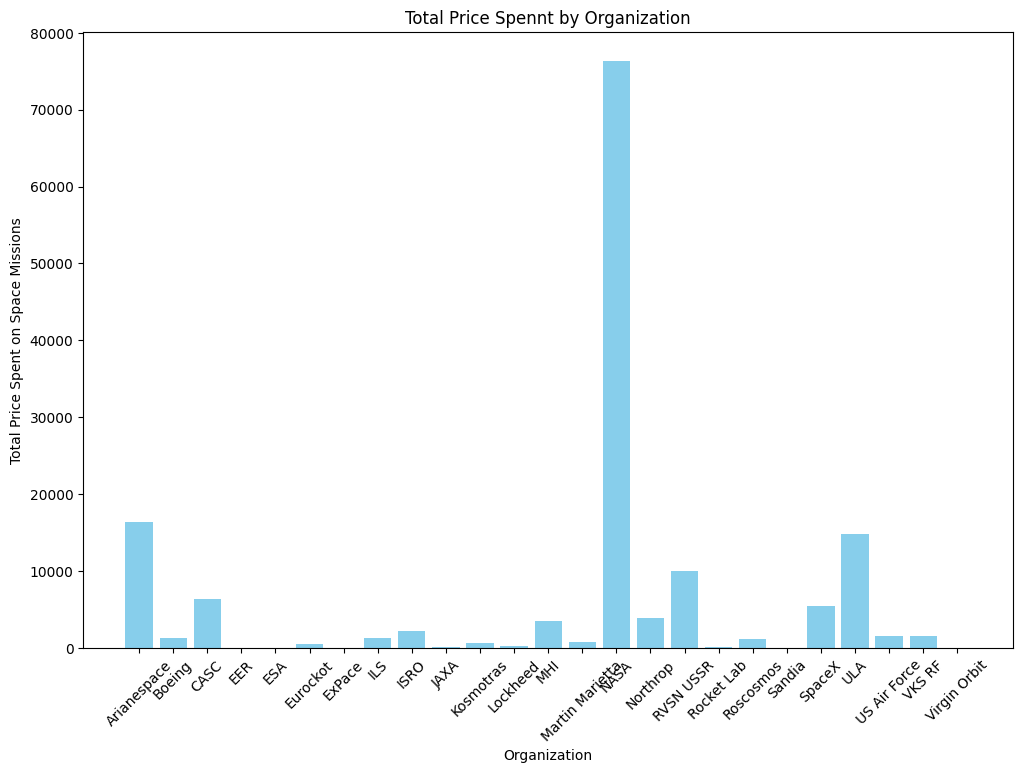

In [93]:
plt.figure(figsize=(12, 8))
plt.bar(total_spent_by_organisation.Organisation, total_spent_by_organisation.Price, color='skyblue')
plt.xlabel('Organization')
plt.ylabel('Total Price Spent on Space Missions')
plt.title('Total Price Spennt by Organization')
plt.xticks(rotation=45)
plt.show()

# Analyse the Amount of Money Spent by Organisation per Launch

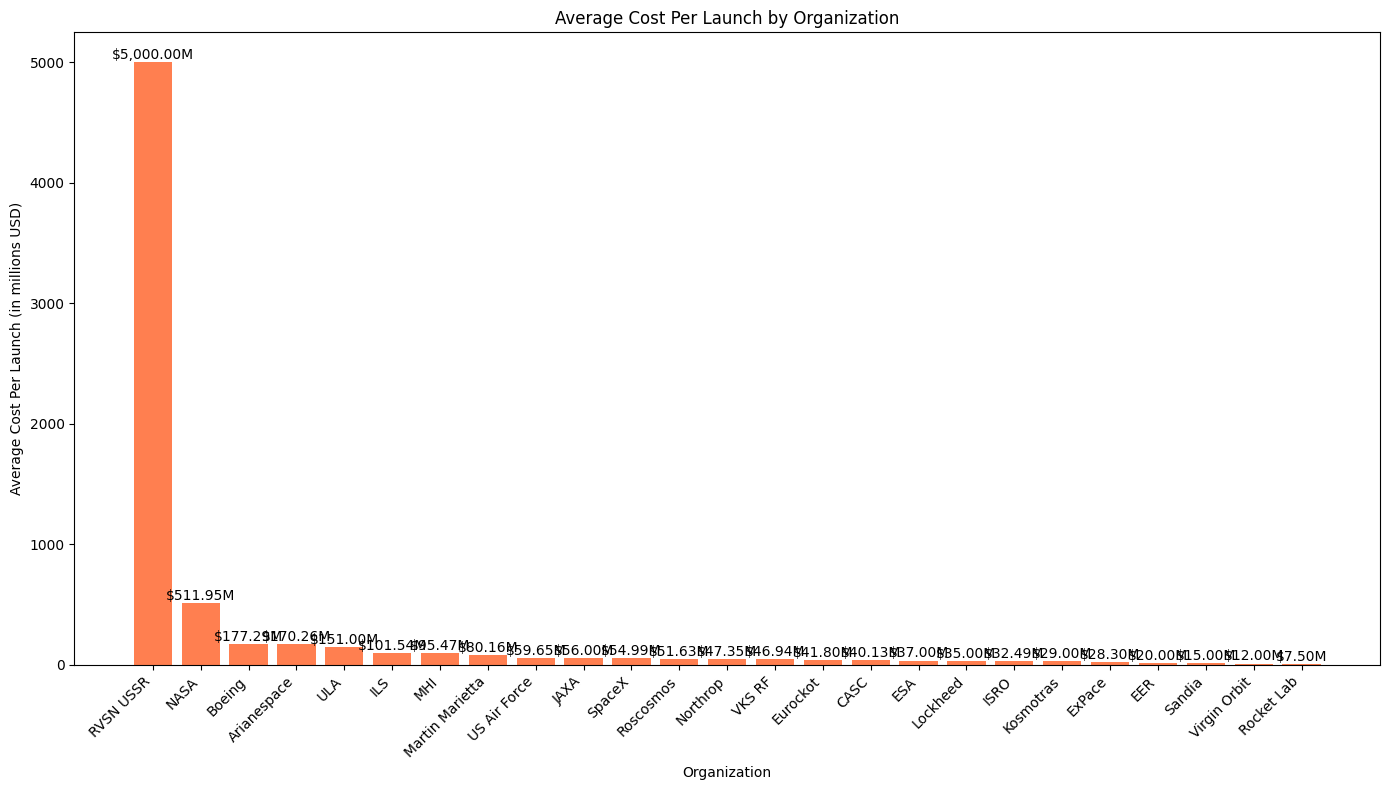

In [95]:
# Step 1: Calculate the number of launches by each organization
launches_per_organisation = df_clean.groupby('Organisation').size().reset_index(name='Launches')

# Step 2: Merge the total spent with the number of launches
merged_df = pd.merge(total_spent_by_organisation, launches_per_organisation, on='Organisation')

# Step 3: Calculate the average cost per launch
merged_df['Cost_Per_Launch'] = merged_df['Price'] / merged_df['Launches']

# Sort by average cost per launch in descending order for better visualization
merged_df = merged_df.sort_values(by='Cost_Per_Launch', ascending=False)

# Step 4: Visualize the data
plt.figure(figsize=(14, 8))
plt.bar(merged_df['Organisation'], merged_df['Cost_Per_Launch'], color='coral')
plt.xlabel('Organization')
plt.ylabel('Average Cost Per Launch (in millions USD)')
plt.title('Average Cost Per Launch by Organization')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Displaying the value on top of each bar
for i in range(len(merged_df)):
    plt.text(i, merged_df['Cost_Per_Launch'].iloc[i] + 0.5, 
             f"${merged_df['Cost_Per_Launch'].iloc[i]:,.2f}M",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Chart the Number of Launches per Year

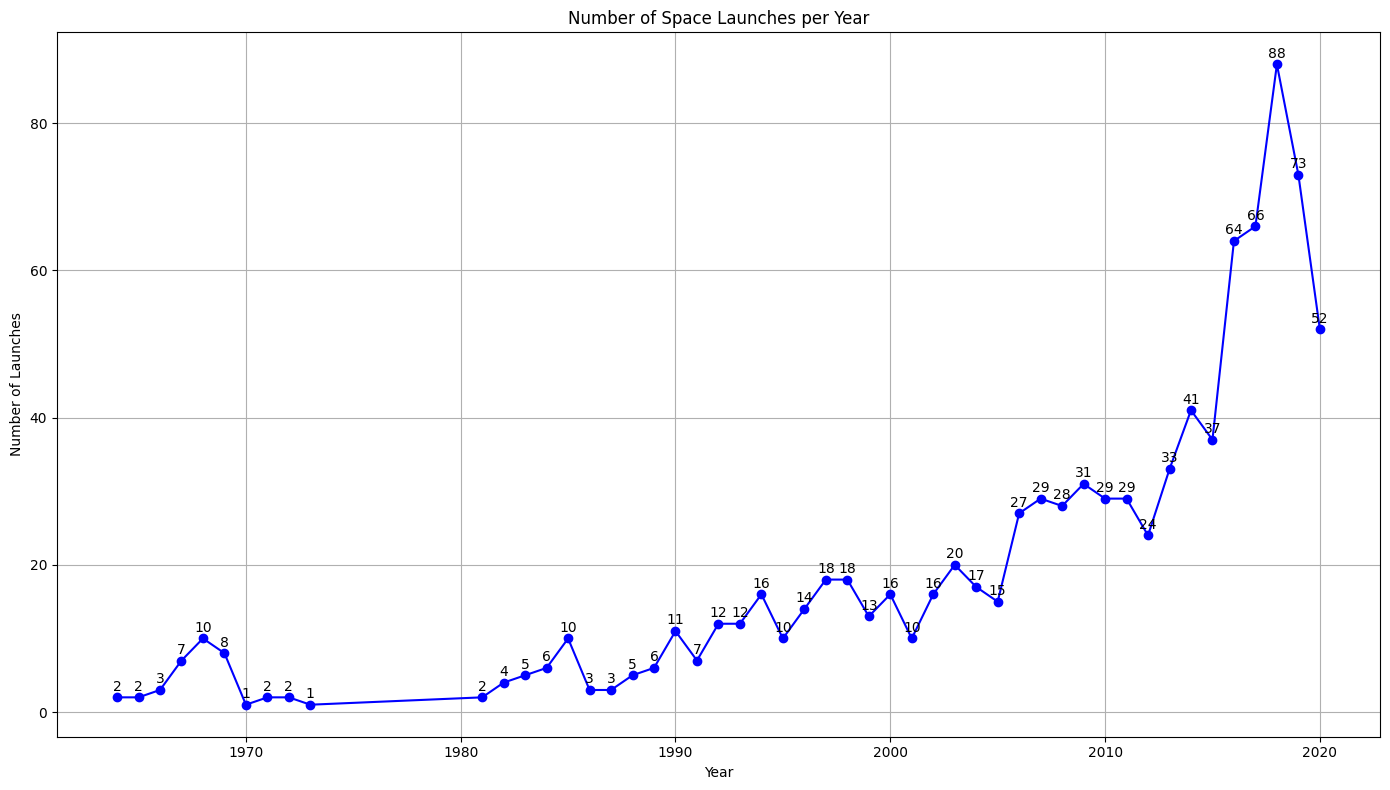

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Ensure the 'Date' column is in datetime format and extract the year
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')  # Convert to datetime, handle errors
df_clean['Year'] = df_clean['Date'].dt.year  # Extract the year

# Step 2: Count the number of launches per year
launches_per_year = df_clean.groupby('Year').size().reset_index(name='Launches')

# Step 3: Plot the number of launches per year
plt.figure(figsize=(14, 8))
plt.plot(launches_per_year['Year'], launches_per_year['Launches'], marker='o', linestyle='-', color='b')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.title('Number of Space Launches per Year')
plt.grid(True)

# Optional: Add labels on each data point
for i in range(len(launches_per_year)):
    plt.text(launches_per_year['Year'].iloc[i], launches_per_year['Launches'].iloc[i] + 0.5,
             f"{launches_per_year['Launches'].iloc[i]}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

In [98]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract year and month
df_clean['YearMonth'] = df_clean['Date'].dt.to_period('M').astype(str)

/var/folders/47/rnc2d43j6mx_d087bt6yh8mm0000gn/T/ipykernel_20168/757175033.py:4: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



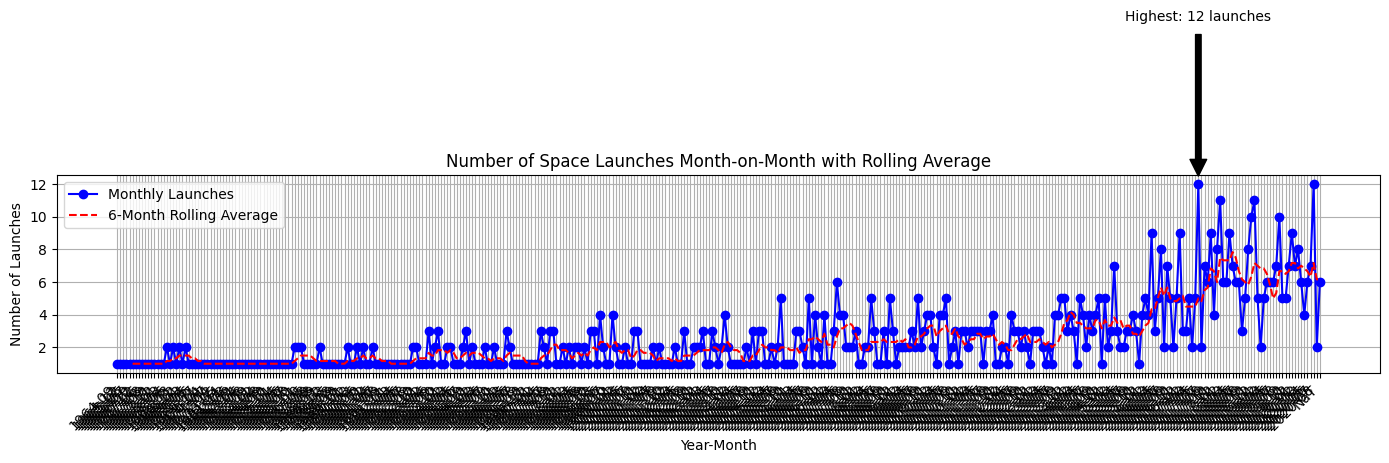

In [100]:
launches_per_month = df_clean.groupby('YearMonth').size().reset_index(name='Launches')
launches_per_month['Rolling_Avg'] = launches_per_month['Launches'].rolling(window=6).mean()
# Plot the number of launches month-on-month with rolling average
plt.figure(figsize=(14, 8))
plt.plot(launches_per_month['YearMonth'], launches_per_month['Launches'], marker='o', linestyle='-', color='b', label='Monthly Launches')
plt.plot(launches_per_month['YearMonth'], launches_per_month['Rolling_Avg'], linestyle='--', color='r', label='6-Month Rolling Average')

plt.xlabel('Year-Month')
plt.ylabel('Number of Launches')
plt.title('Number of Space Launches Month-on-Month with Rolling Average')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.legend()

# Highlight the month with the highest number of launches
max_launches_idx = launches_per_month['Launches'].idxmax()
max_launches_month = launches_per_month.loc[max_launches_idx, 'YearMonth']
max_launches_value = launches_per_month.loc[max_launches_idx, 'Launches']
plt.annotate(f'Highest: {max_launches_value} launches', 
             xy=(max_launches_month, max_launches_value), 
             xytext=(max_launches_month, max_launches_value + 10),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center')

plt.tight_layout()
plt.show()


# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

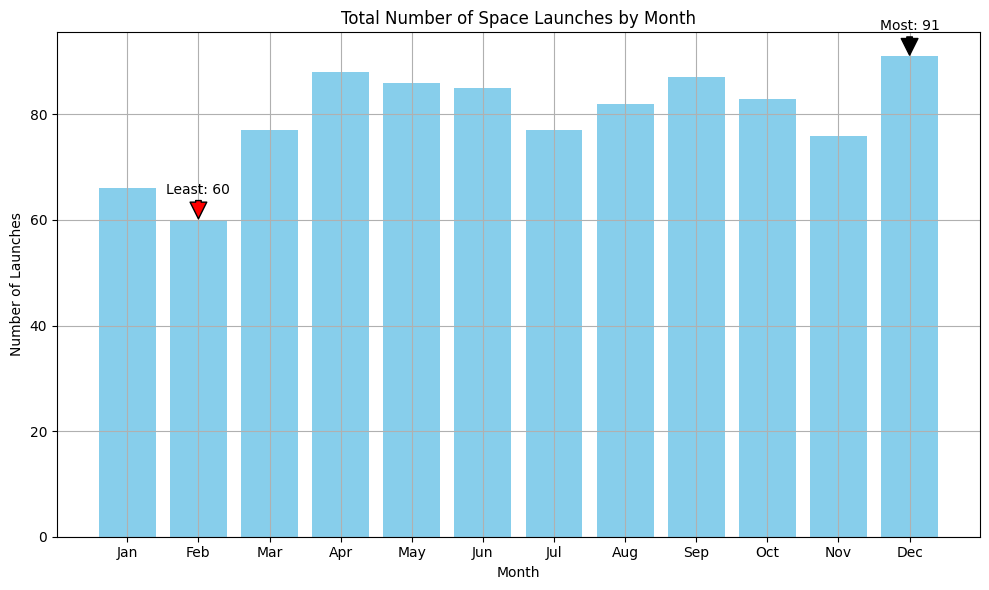

In [101]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract the month from the 'Date' column
df_clean['Month'] = df_clean['Date'].dt.month

# Count the number of launches per month across all years
launches_by_month = df_clean.groupby('Month').size().reset_index(name='Launches')

# Sort the data by month
launches_by_month = launches_by_month.sort_values(by='Month')

# Plot the number of launches per month
plt.figure(figsize=(10, 6))
plt.bar(launches_by_month['Month'], launches_by_month['Launches'], color='skyblue')
plt.xlabel('Month')
plt.ylabel('Number of Launches')
plt.title('Total Number of Space Launches by Month')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)

# Annotate the most and least popular months
max_launches_month = launches_by_month.loc[launches_by_month['Launches'].idxmax(), 'Month']
max_launches_value = launches_by_month.loc[launches_by_month['Launches'].idxmax(), 'Launches']
min_launches_month = launches_by_month.loc[launches_by_month['Launches'].idxmin(), 'Month']
min_launches_value = launches_by_month.loc[launches_by_month['Launches'].idxmin(), 'Launches']

plt.annotate(f'Most: {max_launches_value}', 
             xy=(max_launches_month, max_launches_value), 
             xytext=(max_launches_month, max_launches_value + 5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center')

plt.annotate(f'Least: {min_launches_value}', 
             xy=(min_launches_month, min_launches_value), 
             xytext=(min_launches_month, min_launches_value + 5),
             arrowprops=dict(facecolor='red', shrink=0.05),
             ha='center')

plt.tight_layout()
plt.show()

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

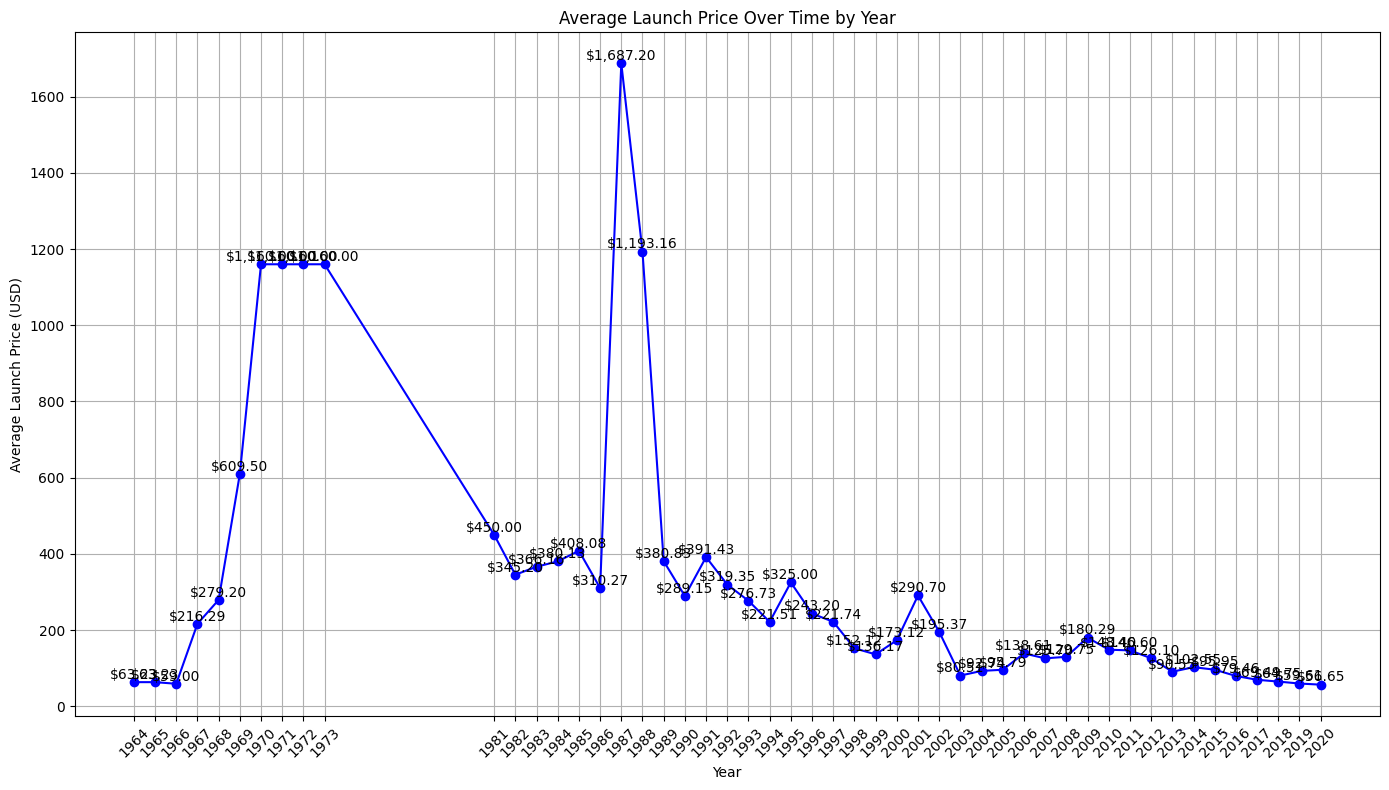

In [103]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract the Year from the 'Date' column
df_clean['Year'] = df_clean['Date'].dt.year

# Calculate the average price of rocket launches per year
average_price_per_year = df_clean.groupby('Year')['Price'].mean().reset_index()

# Plot the average launch price over time
plt.figure(figsize=(14, 8))
plt.plot(average_price_per_year['Year'], average_price_per_year['Price'], marker='o', linestyle='-', color='b')
plt.xlabel('Year')
plt.ylabel('Average Launch Price (USD)')
plt.title('Average Launch Price Over Time by Year')
plt.xticks(average_price_per_year['Year'], rotation=45)
plt.grid(True)

# Optional: Add labels on each data point
for i in range(len(average_price_per_year)):
    plt.text(average_price_per_year['Year'].iloc[i], average_price_per_year['Price'].iloc[i] + 0.5,
             f"${average_price_per_year['Price'].iloc[i]:,.2f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

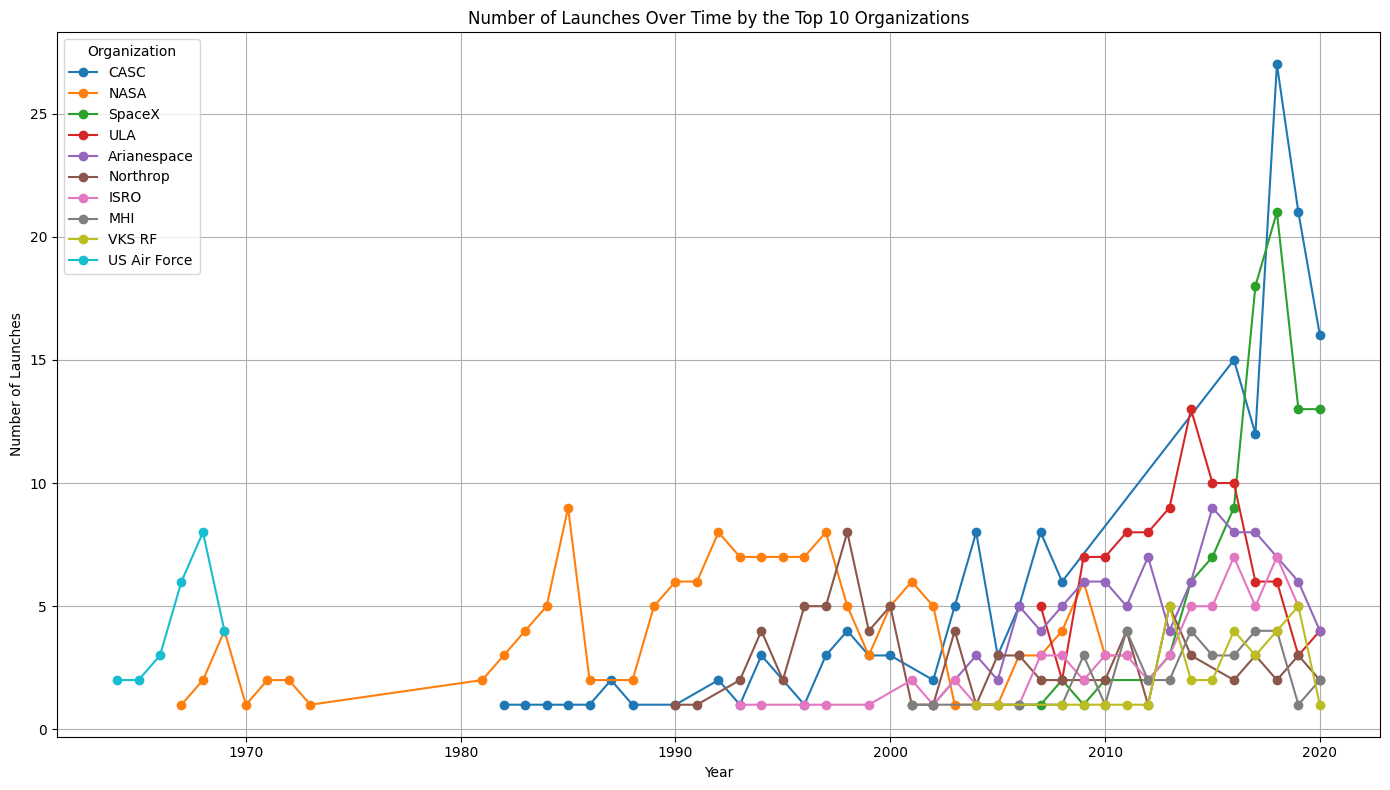

In [104]:

df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Extract the Year from the 'Date' column
df_clean['Year'] = df_clean['Date'].dt.year

# Step 1: Identify the top 10 organizations by the total number of launches
top_10_organisations = df_clean['Organisation'].value_counts().head(10).index

# Filter the DataFrame to include only the top 10 organizations
df_top_10 = df_clean[df_clean['Organisation'].isin(top_10_organisations)]

# Step 2: Calculate the number of launches per year for each organization
launches_per_year_org = df_top_10.groupby(['Year', 'Organisation']).size().reset_index(name='Launches')

# Step 3: Plot the number of launches over time for each organization
plt.figure(figsize=(14, 8))

# Loop through each organization and plot its data
for organisation in top_10_organisations:
    org_data = launches_per_year_org[launches_per_year_org['Organisation'] == organisation]
    plt.plot(org_data['Year'], org_data['Launches'], marker='o', linestyle='-', label=organisation)

plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.title('Number of Launches Over Time by the Top 10 Organizations')
plt.legend(title='Organization')
plt.grid(True)

plt.tight_layout()
plt.show()


# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [111]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
cold_war_data = df_clean[df_clean['Date'].dt.year <= 1991]
df_clean[df_clean.Cou]

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country,Country_Code,Year,YearMonth,Month
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,USA,USA,"2,020.00",2020-08,8.00
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,China,CHN,"2,020.00",2020-08,8.00
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,Kazakhstan,KAZ,"2,020.00",2020-07,7.00
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success,USA,USA,"2,020.00",2020-07,7.00
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China",2020-07-25 03:13:00+00:00,"Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success,China,CHN,"2,020.00",2020-07,7.00
...,...,...,...,...,...,...,...,...,...,...,...,...
3855,US Air Force,"SLC-4W, Vandenberg AFB, California, USA",1966-07-29 18:43:00+00:00,Titan IIIB | KH-8,StatusRetired,59.00,Success,USA,USA,"1,966.00",1966-07,7.00
3971,US Air Force,"SLC-20, Cape Canaveral AFS, Florida, USA",1965-05-06 15:00:00+00:00,Titan IIIA | LES 2 & LCS 1,StatusRetired,63.23,Success,USA,USA,"1,965.00",1965-05,5.00
3993,US Air Force,"SLC-20, Cape Canaveral AFS, Florida, USA",1965-02-11 15:19:00+00:00,Titan IIIA | LES 1,StatusRetired,63.23,Success,USA,USA,"1,965.00",1965-02,2.00
4000,US Air Force,"SLC-20, Cape Canaveral AFS, Florida, USA",1964-12-10 16:52:00+00:00,Titan IIIA | Transtage 2,StatusRetired,63.23,Success,USA,USA,"1,964.00",1964-12,12.00


## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [106]:
ussr_countries = ['Russia', 'Russian Federation', 'Kazakhstan', 'Ukraine']

# Filter the data for the USSR and USA during the Cold War
ussr_launches = cold_war_data[cold_war_data['Country'].isin(ussr_countries)]
usa_launches = cold_war_data[cold_war_data['Country'] == 'USA']

# Sum the number of launches for each
ussr_total_launches = ussr_launches.shape[0]
usa_total_launches = usa_launches.shape[0]

# Create a DataFrame to hold the totals
launches_comparison = pd.DataFrame({
    'Country': ['USSR (including former Soviet Republics)', 'USA'],
    'Launches': [ussr_total_launches, usa_total_launches]
})


In [108]:
fig = px.pie(launches_comparison, values='Launches', names='Country', 
             title='Total Number of Launches During the Cold War: USSR vs USA')

# Show the pie chart
fig.show(renderer='browser')


## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

## Chart the Total Number of Mission Failures Year on Year.

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 